In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# import gpax
# import jax.numpy as jnp
# import jax.random as jra
# import matplotlib.pyplot as plt

# # --- 1. CONFIGURATION & DATA GENERATION ---
# key_train, key_mc = gpax.utils.get_keys()

# # Ground truth: y depends on Control(x1, x2) and Random Covariate(c)
# def ground_truth(x):
#     # A function where 'c' significantly shifts the position of the best x
#     return (jnp.sin(10 * x[:, 0]) * jnp.cos(10 * x[:, 1])) + (x[:, 2] * 2.0 * x[:, 0])

# # Generate training data
# n_train = 25
# X_train = jra.uniform(key_train, (n_train, 3))
# y_train = ground_truth(X_train)
# y_train_norm = (y_train - y_train.mean()) / y_train.std()

# # --- 2. MODEL TRAINING ---
# # Train on full 3D data (x1, x2, c)
# model = gpax.ExactGP(input_dim=3, kernel='Matern')
# model.fit(key_train, X_train, y_train_norm, num_chains=1, num_samples=250)

# # --- 3. ROBUST ACQUISITION SETUP ---

# # A. Create the grid for X (Control variables only)
# resolution = 40
# x1_lin = jnp.linspace(0, 1, resolution)
# x2_lin = jnp.linspace(0, 1, resolution)
# X1, X2 = jnp.meshgrid(x1_lin, x2_lin)
# # Shape: (1600, 2)
# X_grid_2d = jnp.column_stack([X1.ravel(), X2.ravel()])

# # B. Sample the Covariate Distribution (Monte Carlo)
# # We assume the future 'c' will behave like the 'c' we observed in training.
# # We draw 20 random samples of 'c' to average over.
# n_mc_samples = 20
# c_history = X_train[:, 2] # The column of observed covariates
# c_samples = jra.choice(key_mc, c_history, shape=(n_mc_samples,), replace=True)

# # --- 4. BATCHED INTEGRATION (The "Robust" Step) ---

# def compute_robust_acq(key, model, X_grid, c_samples):
#     # X_grid shape: (N_grid, 2)
#     # c_samples shape: (N_mc,)

#     n_grid = X_grid.shape[0]
#     n_mc = c_samples.shape[0]

#     # We need to evaluate every x against every c.
#     # Total evaluations = N_grid * N_mc = 1600 * 20 = 32,000 evaluations.

#     # 1. Repeat X_grid for each MC sample
#     # Shape becomes (N_grid * N_mc, 2)
#     # [x1, x1, ... x2, x2, ...]
#     X_repeated = jnp.repeat(X_grid, n_mc, axis=0)

#     # 2. Tile c_samples for the whole grid
#     # Shape becomes (N_grid * N_mc, 1)
#     # [c1, c2, ... c1, c2, ...]
#     c_tiled = jnp.tile(c_samples, n_grid)[:, None]

#     # 3. Stack to create (N_grid * N_mc, 3) input
#     X_full_batch = jnp.hstack([X_repeated, c_tiled])

#     # 4. Compute Acquisition in chunks to save memory
#     # We process 1000 items at a time
#     batch_size = 1000
#     n_total = X_full_batch.shape[0]
#     acq_list = []

#     print(f"Calculating robust acquisition over {n_total} scenarios...")

#     for i in range(0, n_total, batch_size):
#         batch_X = X_full_batch[i : i + batch_size]
#         key, subkey = jra.split(key)

#         # Standard EI calculation on this batch
#         acq_batch = gpax.acquisition.EI(
#             subkey, model, batch_X, best_f=y_train_norm.max(), maximize=True
#         )
#         acq_list.append(acq_batch)

#     # Combine results: Shape (N_grid * N_mc, )
#     all_acq_values = jnp.concatenate(acq_list)

#     # 5. Reshape and Average
#     # Reshape to (N_grid, N_mc) so we can average across the MC dimension
#     all_acq_matrix = all_acq_values.reshape(n_grid, n_mc)

#     # Take the mean across axis 1 (integrating out c)
#     robust_acq = jnp.mean(all_acq_matrix, axis=1)

#     return robust_acq

# # Execute
# robust_acq_values = compute_robust_acq(key_pred, model, X_grid_2d, c_samples)

# # --- 5. PLOTTING ---
# robust_map = robust_acq_values.reshape(resolution, resolution)
# best_idx = jnp.argmax(robust_acq_values)

# plt.figure(figsize=(10, 8))
# contour = plt.contourf(X1, X2, robust_map, levels=50, cmap='plasma')
# plt.colorbar(contour, label='Integrated Expected Improvement')

# # Plot best robust point
# plt.scatter(X_grid_2d[best_idx, 0], X_grid_2d[best_idx, 1],
#             c='lime', marker='*', s=300, edgecolors='black', label='Best Robust Point')

# # Plot training data (projected to 2D)
# plt.scatter(X_train[:, 0], X_train[:, 1], c='black', alpha=0.5, label='Training Data')

# plt.title('Robust Acquisition Landscape\n(Averaged over random covariate noise)')
# plt.xlabel('x1'); plt.ylabel('x2')
# plt.legend()
# plt.show()

In [12]:
import os
import time
from rtm_pymmcore.data_structures import Channel, StimTreatment, SegmentationMethod
import rtm_pymmcore.utils as utils
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import gpax
import pandas as pd

In [13]:
from rtm_pymmcore.agents.bo_optimization_gpax import (
    BOptGPAX,
    BO_Parameter,
    BO_Objective,
    StandardScalerBounds,
    BO_Covariate,
    mock_df_results,
)

=== BO iteration 1/12 ===


sample: 100%|██████████| 1200/1200 [00:00<00:00, 1274.12it/s, 7 steps of size 5.87e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.85      0.63      0.69      0.09      1.79   1086.35      1.00
k_length[1]      1.42      1.27      1.04      0.05      3.11    737.76      1.00
k_length[2]      4.37      1.69      4.15      1.68      6.60    903.20      1.00
    k_scale      1.47      0.87      1.26      0.34      2.59    838.79      1.00
      noise      0.03      0.01      0.03      0.01      0.04   1207.52      1.00

Computing robust acquisition over 1480 scenarios (74 grid points x 20 covariate samples)...
  best_f (scaled): 2.039944
  Acq values stats: min=0.000000, max=0.092084, mean=0.017379
  Robust acq stats: min=0.000001, max=0.045841
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 2.039944
  Acq values stats: min=0.000000, max=0.091636, mean=0.016859
  Robust acq stats: min=0.000000, max=0.045114


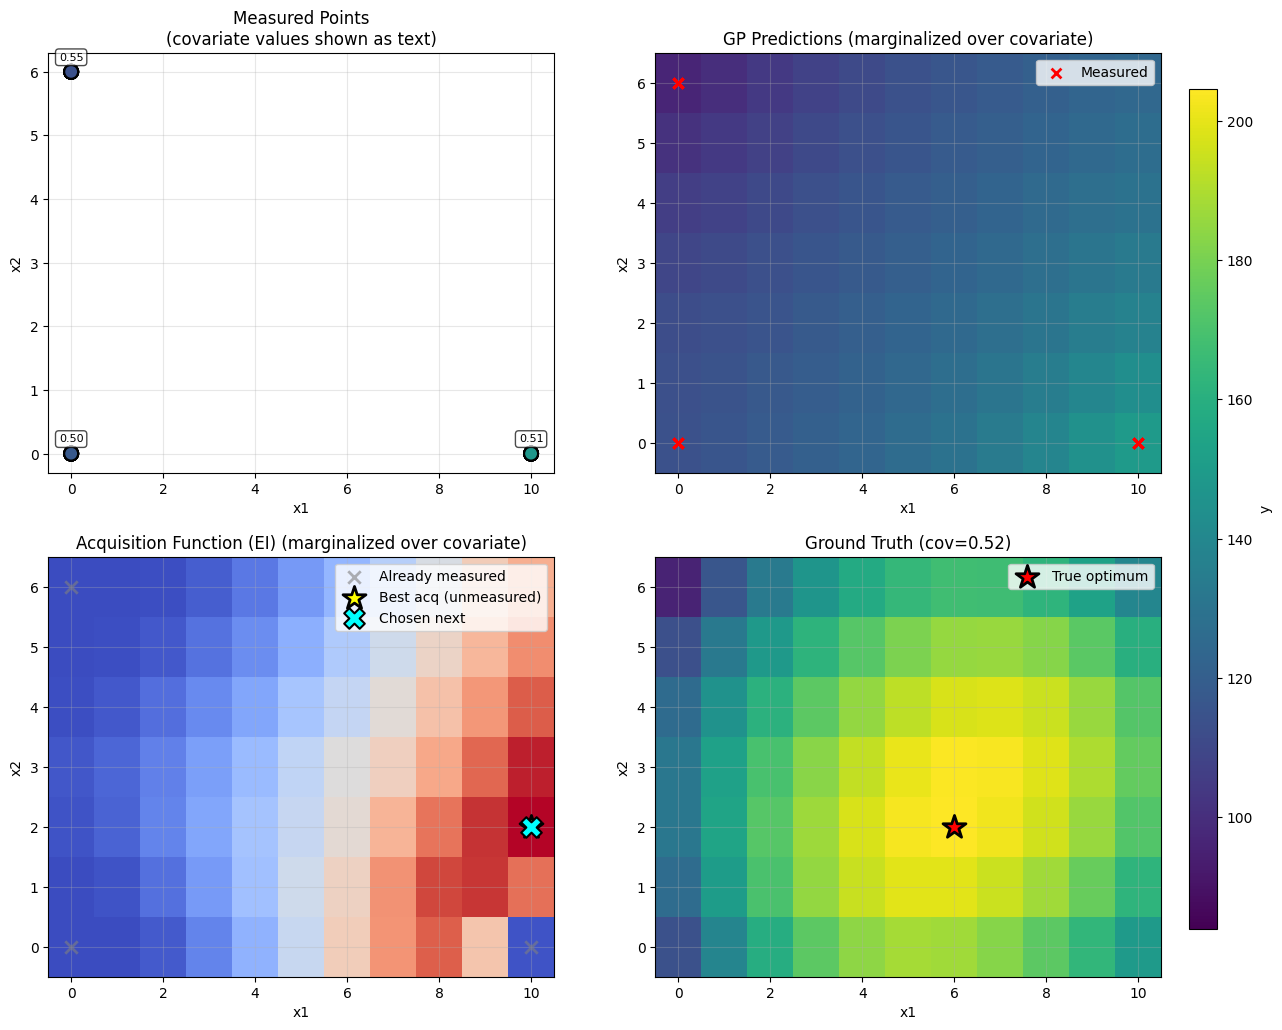

{'x1': np.float64(10.0), 'x2': np.float64(2.0)}
=== BO iteration 2/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 433.83it/s, 7 steps of size 4.68e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.74      0.53      0.61      0.06      1.43    696.58      1.00
k_length[1]      1.49      0.85      1.33      0.13      2.65    626.89      1.00
k_length[2]      5.74      2.08      5.45      2.51      9.02    816.34      1.00
    k_scale      1.51      0.91      1.29      0.39      2.62    632.73      1.00
      noise      0.02      0.01      0.02      0.01      0.02    808.85      1.00

Computing robust acquisition over 1460 scenarios (73 grid points x 20 covariate samples)...
  best_f (scaled): 1.913092
  Acq values stats: min=0.000000, max=0.149663, mean=0.025342
  Robust acq stats: min=0.000000, max=0.103253
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.913092
  Acq values stats: min=0.000000, max=0.148536, mean=0.023523
  Robust acq stats: min=0.000000, max=0.104793


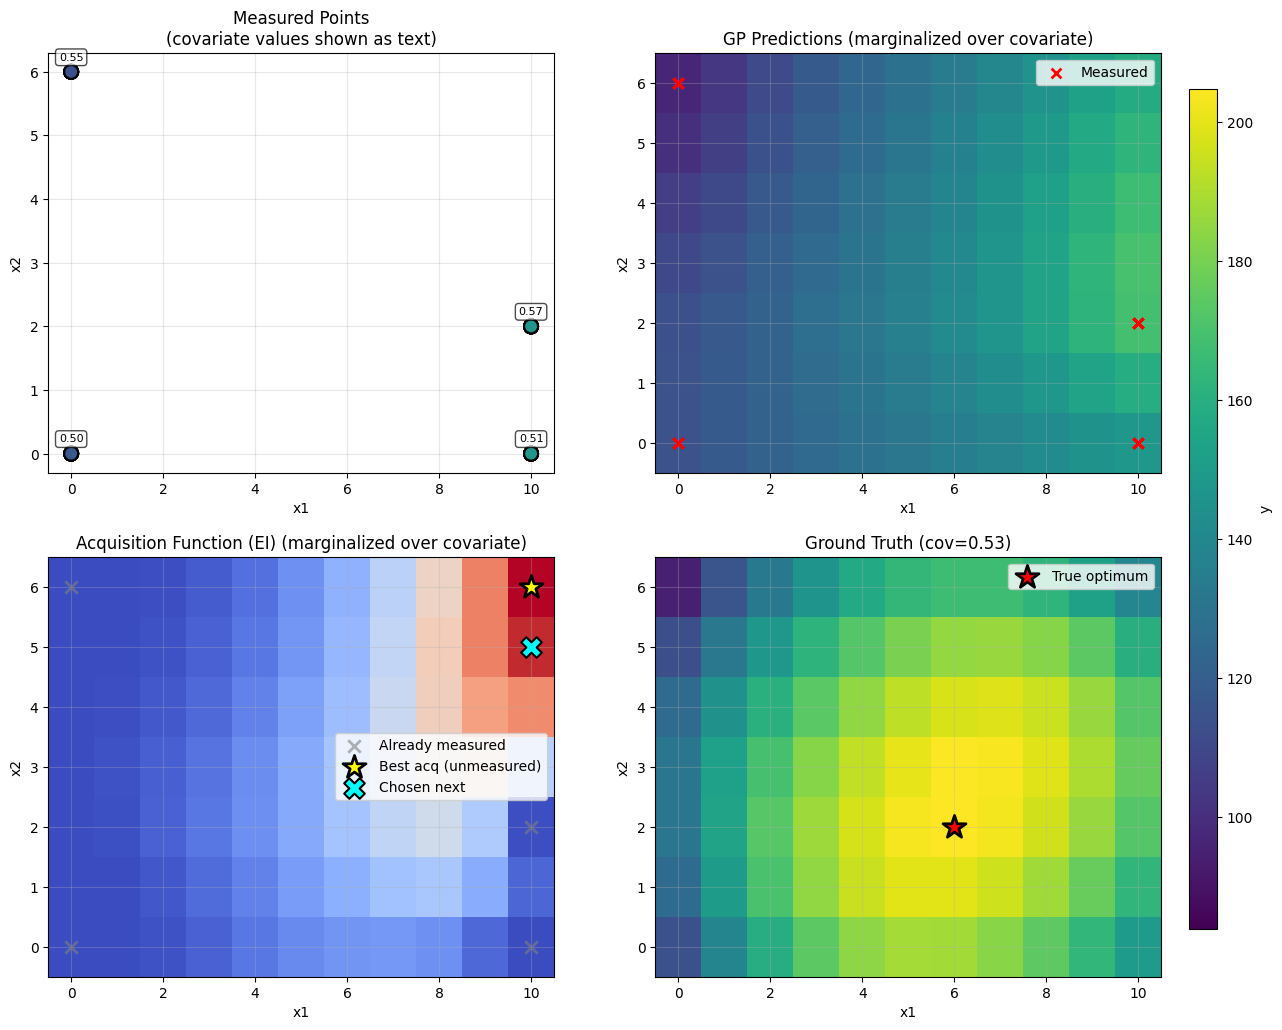

{'x1': np.float64(10.0), 'x2': np.float64(5.0)}
=== BO iteration 3/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 455.57it/s, 7 steps of size 4.00e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.72      0.51      0.60      0.06      1.42    687.79      1.00
k_length[1]      1.46      0.55      1.44      0.55      2.27    554.41      1.00
k_length[2]      5.88      1.87      5.55      2.79      8.47    756.06      1.00
    k_scale      1.51      0.87      1.31      0.41      2.65    669.15      1.00
      noise      0.02      0.00      0.01      0.01      0.02    759.65      1.00

Computing robust acquisition over 1440 scenarios (72 grid points x 20 covariate samples)...
  best_f (scaled): 1.807549
  Acq values stats: min=0.000000, max=0.080756, mean=0.012907
  Robust acq stats: min=0.000000, max=0.043622
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.807549
  Acq values stats: min=0.000000, max=0.079570, mean=0.012072
  Robust acq stats: min=0.000000, max=0.043932


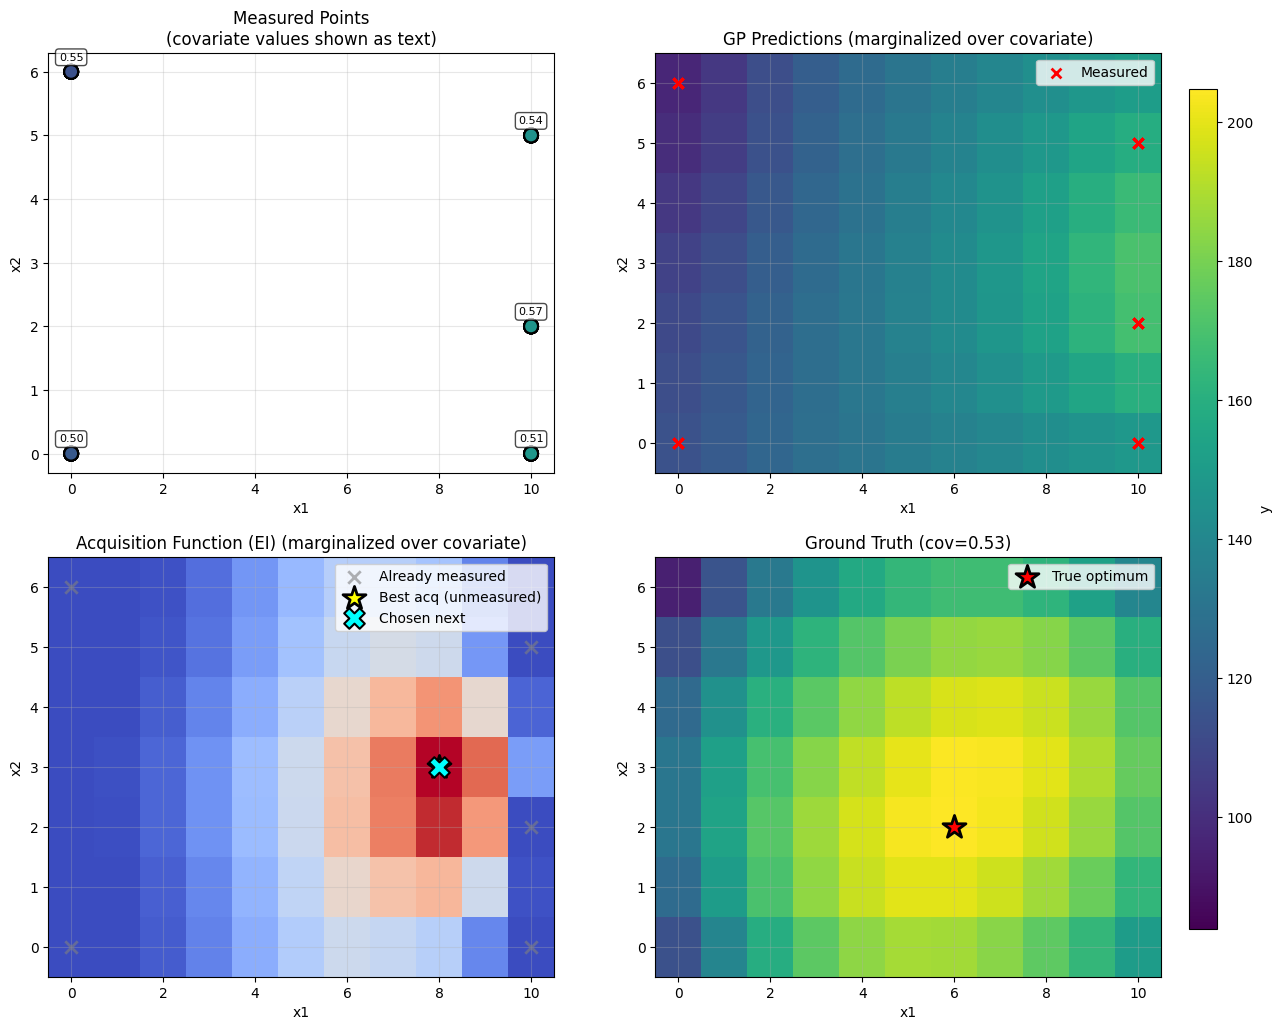

{'x1': np.float64(8.0), 'x2': np.float64(3.0)}
=== BO iteration 4/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 432.12it/s, 7 steps of size 4.92e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.62      0.36      0.56      0.11      1.12    472.98      1.00
k_length[1]      1.50      0.60      1.50      0.44      2.38    508.50      1.00
k_length[2]      7.13      2.27      6.77      3.72     10.54    759.42      1.00
    k_scale      1.54      0.90      1.32      0.45      2.69    671.31      1.00
      noise      0.01      0.00      0.01      0.01      0.01    883.76      1.00

Computing robust acquisition over 1420 scenarios (71 grid points x 20 covariate samples)...
  best_f (scaled): 1.641291
  Acq values stats: min=0.000000, max=0.110791, mean=0.029753
  Robust acq stats: min=0.000000, max=0.099416
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.641291
  Acq values stats: min=0.000000, max=0.103028, mean=0.025412
  Robust acq stats: min=0.000000, max=0.094047


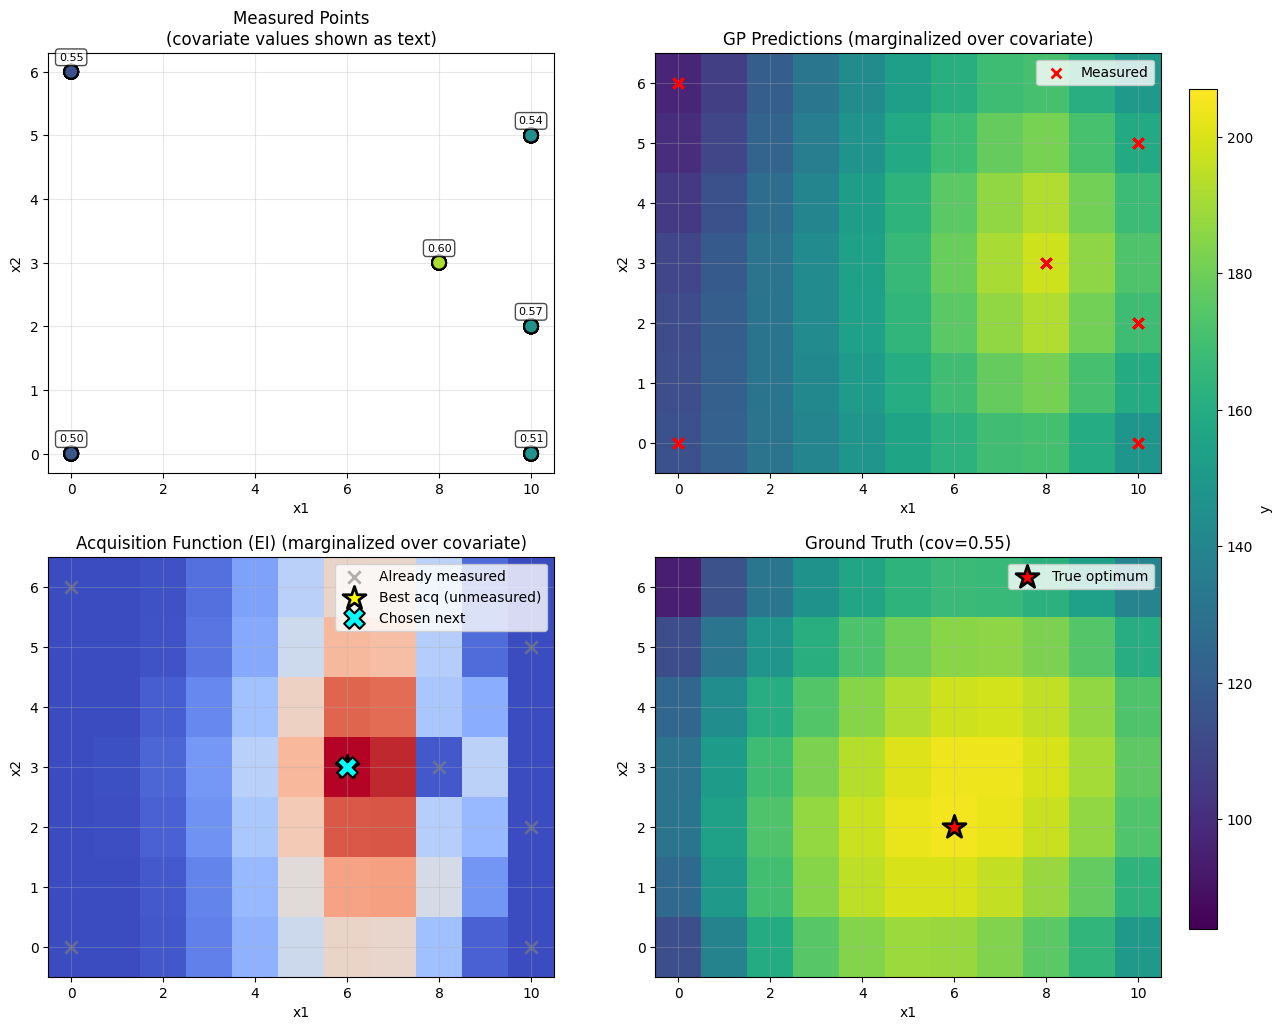

{'x1': np.float64(6.0), 'x2': np.float64(3.0)}
=== BO iteration 5/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 336.31it/s, 15 steps of size 3.46e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.95      0.54      0.84      0.24      1.66    528.77      1.00
k_length[1]      1.49      0.67      1.48      0.16      2.36    474.08      1.00
k_length[2]      7.69      2.25      7.36      4.14     10.94    525.35      1.00
    k_scale      1.57      0.91      1.32      0.47      2.77    482.84      1.00
      noise      0.01      0.00      0.01      0.01      0.01    488.26      1.00

Computing robust acquisition over 1400 scenarios (70 grid points x 20 covariate samples)...
  best_f (scaled): 1.396029
  Acq values stats: min=0.000000, max=0.100054, mean=0.019016
  Robust acq stats: min=0.000000, max=0.069296
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.396029
  Acq values stats: min=0.000000, max=0.087016, mean=0.016235
  Robust acq stats: min=0.000000, max=0.068941


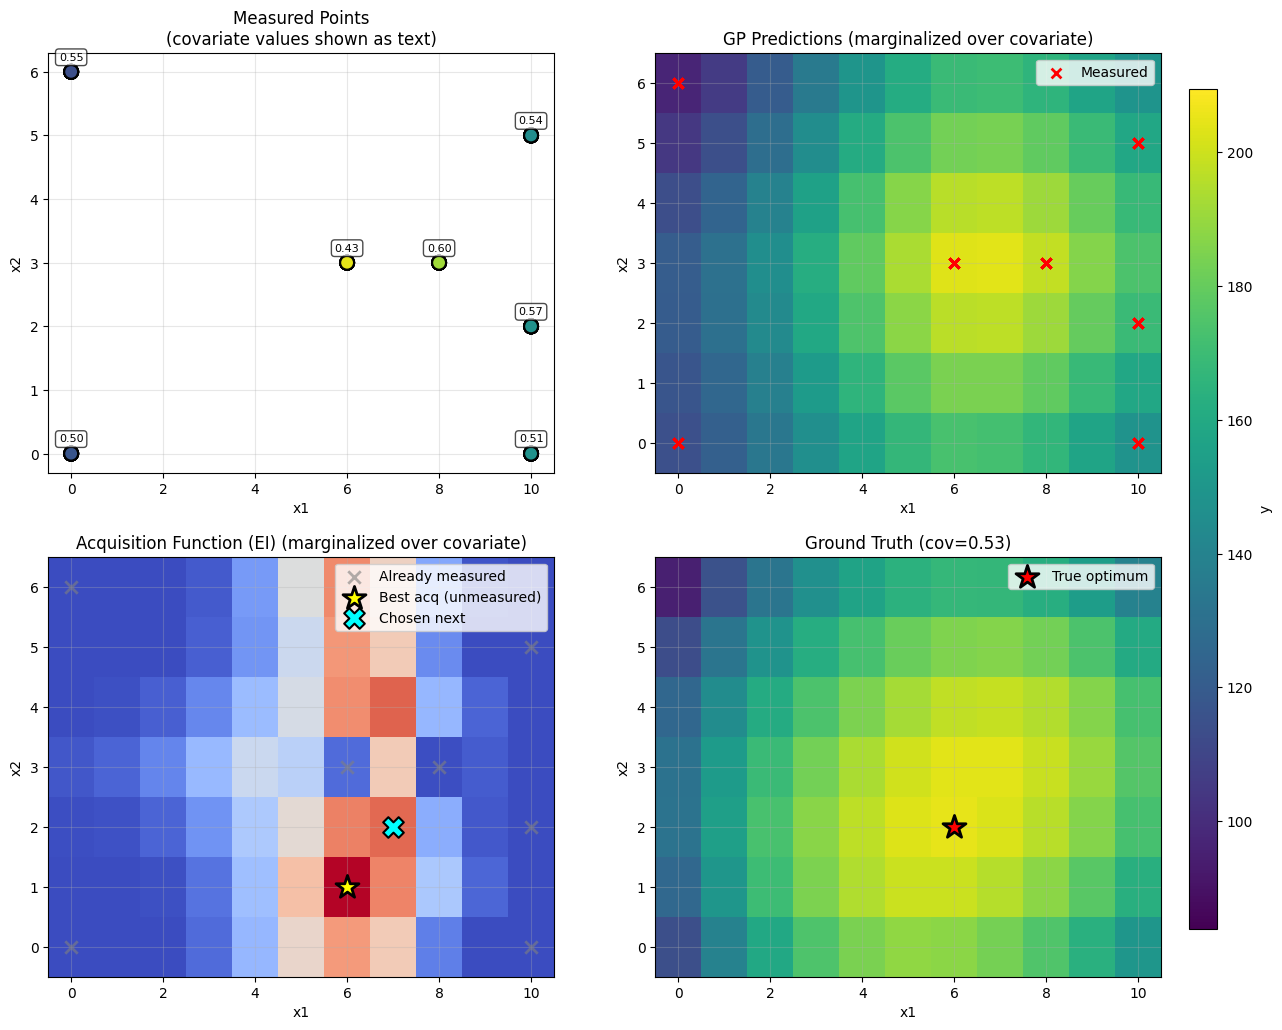

{'x1': np.float64(7.0), 'x2': np.float64(2.0)}
=== BO iteration 6/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 382.60it/s, 7 steps of size 4.51e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.13      0.43      1.09      0.40      1.74    451.25      1.01
k_length[1]      1.87      0.65      1.84      0.78      2.87    356.64      1.00
k_length[2]      8.74      2.48      8.39      4.77     12.49    437.65      1.01
    k_scale      2.04      1.30      1.71      0.57      3.68    375.99      1.01
      noise      0.01      0.00      0.01      0.01      0.01    991.83      1.01

Computing robust acquisition over 1380 scenarios (69 grid points x 20 covariate samples)...
  best_f (scaled): 1.267534
  Acq values stats: min=0.000000, max=0.028260, mean=0.003454
  Robust acq stats: min=0.000000, max=0.021005
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.267534
  Acq values stats: min=0.000000, max=0.023481, mean=0.002316
  Robust acq stats: min=0.000000, max=0.016645


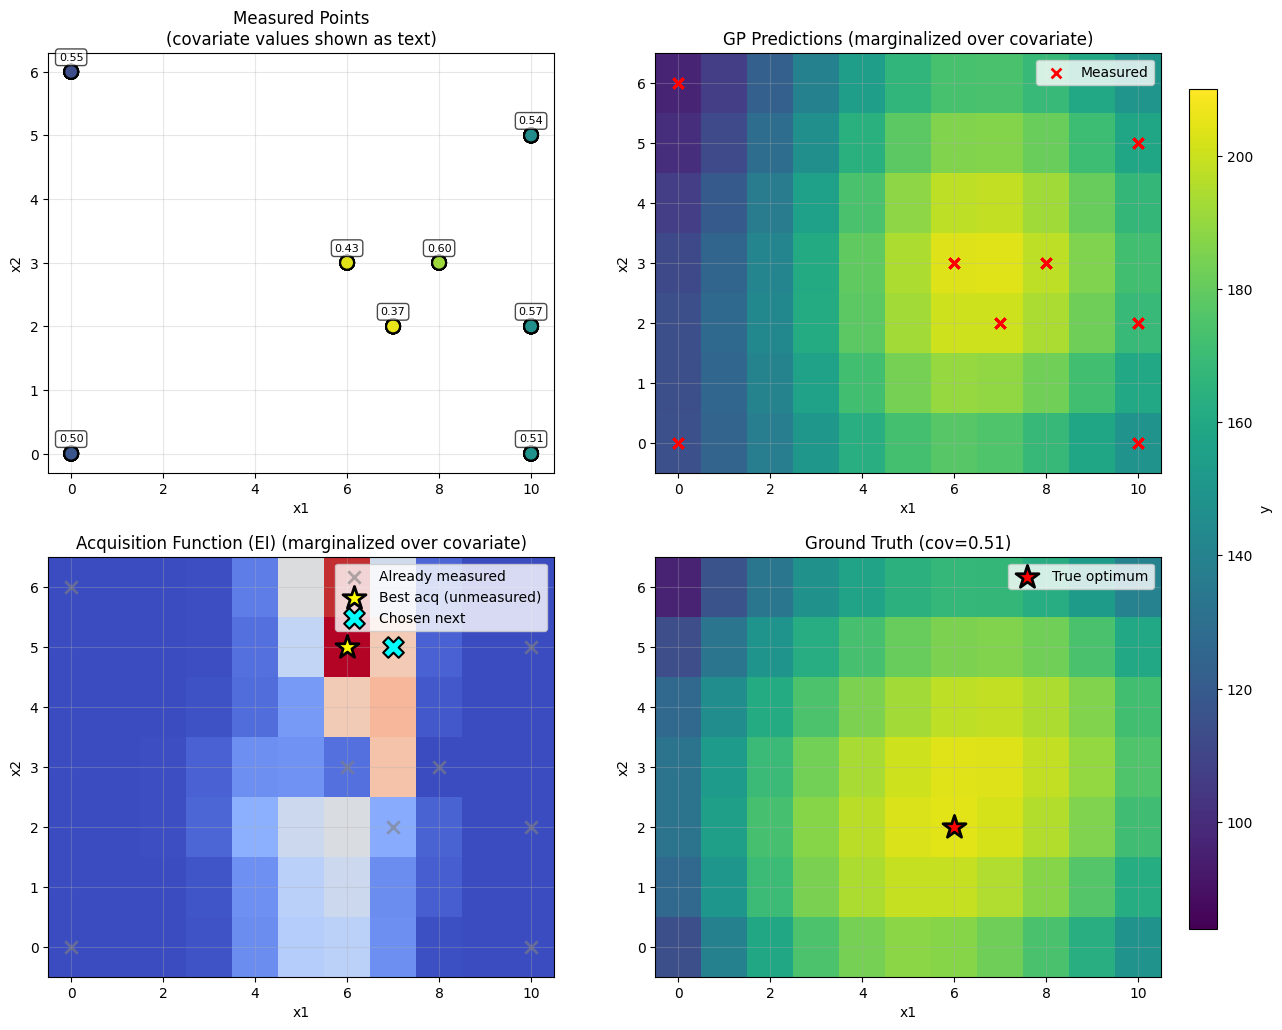

{'x1': np.float64(7.0), 'x2': np.float64(5.0)}
=== BO iteration 7/12 ===


sample: 100%|██████████| 1200/1200 [00:04<00:00, 291.64it/s, 15 steps of size 3.12e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.21      0.45      1.17      0.46      1.92    347.80      1.00
k_length[1]      2.01      0.59      1.95      1.01      2.85    446.66      1.00
k_length[2]      9.38      2.60      9.04      5.11     13.23    346.06      1.00
    k_scale      2.26      1.38      1.90      0.51      3.99    360.25      1.00
      noise      0.01      0.00      0.01      0.01      0.01    525.41      1.00

Computing robust acquisition over 1360 scenarios (68 grid points x 20 covariate samples)...
  best_f (scaled): 1.231873
  Acq values stats: min=0.000000, max=0.023706, mean=0.001347
  Robust acq stats: min=0.000000, max=0.010440
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.231873
  Acq values stats: min=0.000000, max=0.023605, mean=0.001163
  Robust acq stats: min=0.000000, max=0.010086


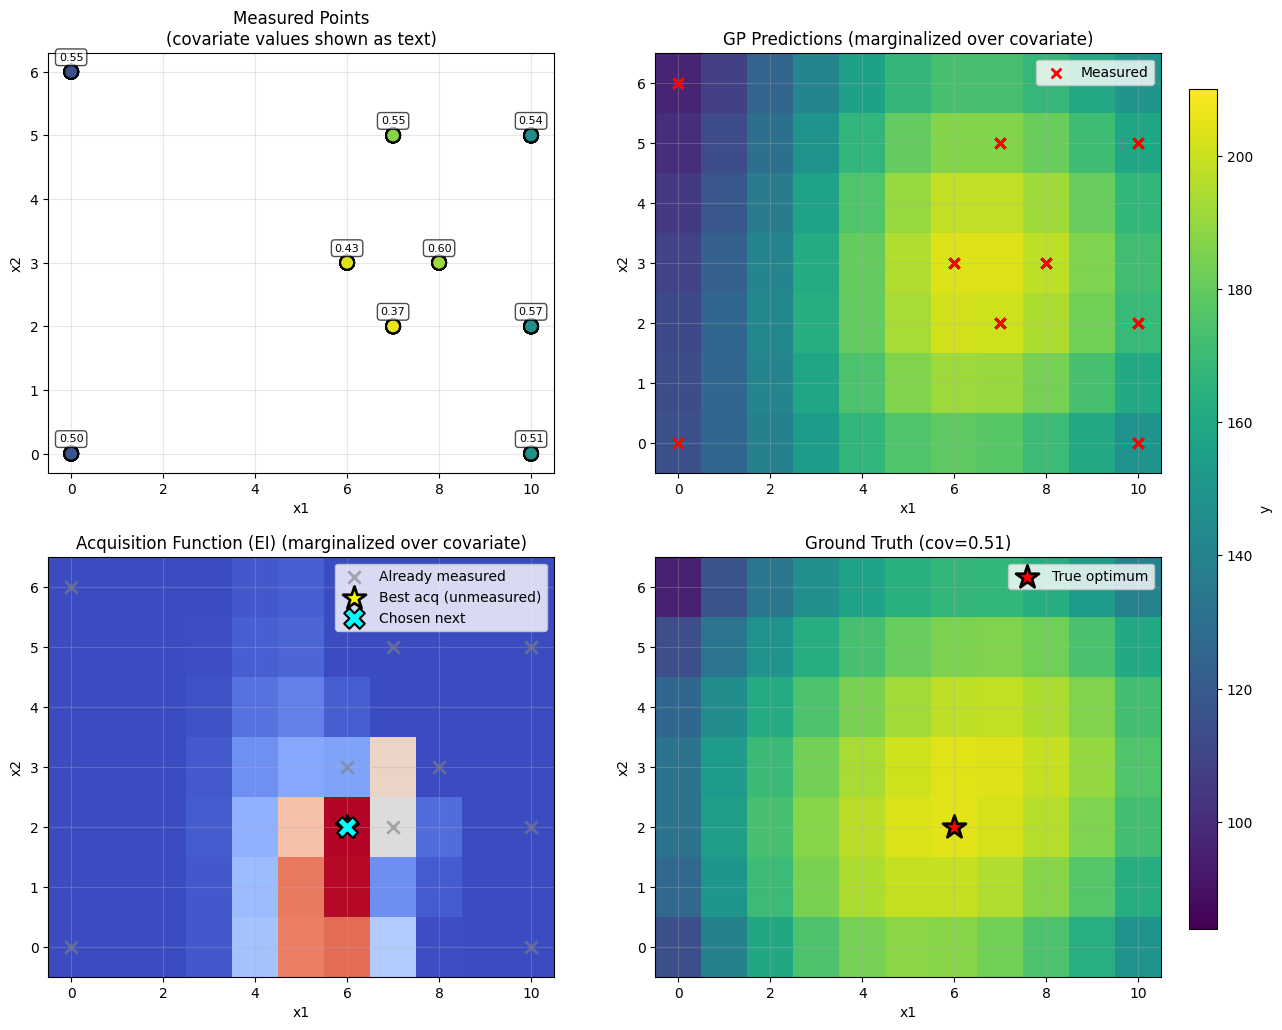

{'x1': np.float64(6.0), 'x2': np.float64(2.0)}
=== BO iteration 8/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 310.44it/s, 15 steps of size 3.99e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.43      0.49      1.40      0.68      2.20    268.72      1.01
k_length[1]      2.33      0.67      2.27      1.34      3.43    302.76      1.00
k_length[2]     10.40      2.96      9.98      5.92     14.91    421.88      1.00
    k_scale      3.00      2.07      2.39      0.61      5.70    240.80      1.00
      noise      0.01      0.00      0.01      0.01      0.01   1213.34      1.00

Computing robust acquisition over 1340 scenarios (67 grid points x 20 covariate samples)...
  best_f (scaled): 1.224334
  Acq values stats: min=0.000000, max=0.000698, mean=0.000005
  Robust acq stats: min=0.000000, max=0.000112
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.224334
  Acq values stats: min=0.000000, max=0.001240, mean=0.000003
  Robust acq stats: min=0.000000, max=0.000079


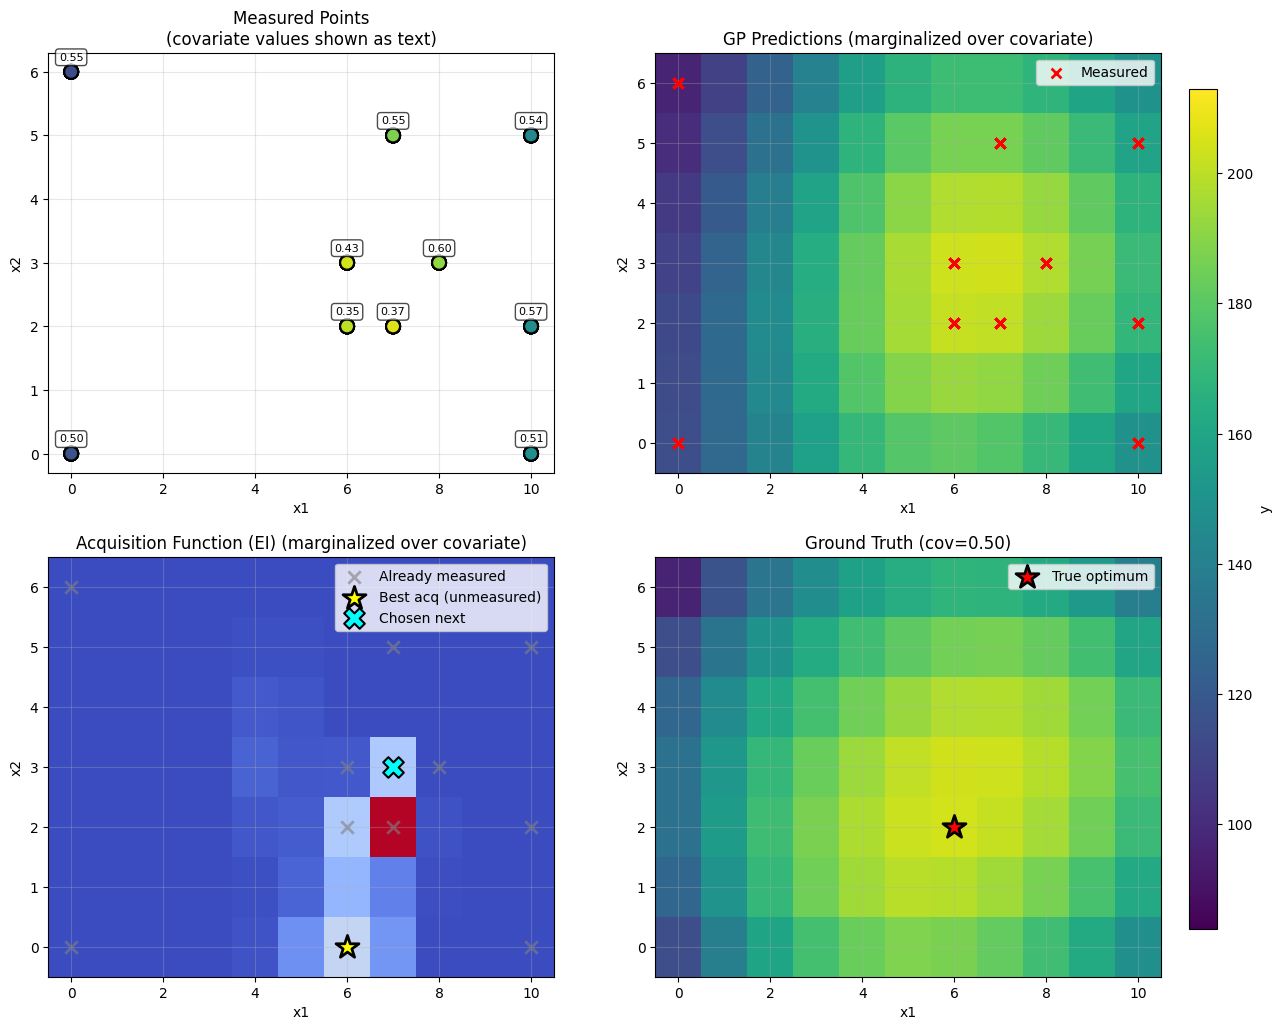

{'x1': np.float64(7.0), 'x2': np.float64(3.0)}
=== BO iteration 9/12 ===


sample: 100%|██████████| 1200/1200 [00:04<00:00, 253.90it/s, 15 steps of size 3.49e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.53      0.46      1.46      0.76      2.20    435.98      1.00
k_length[1]      2.42      0.65      2.38      1.39      3.45    449.07      1.00
k_length[2]     10.70      2.88     10.45      6.26     15.04    589.58      1.00
    k_scale      3.18      2.09      2.53      0.72      5.90    444.44      1.00
      noise      0.01      0.00      0.01      0.01      0.01    558.34      1.00

Computing robust acquisition over 1320 scenarios (66 grid points x 20 covariate samples)...
  best_f (scaled): 1.141072
  Acq values stats: min=0.000000, max=0.000205, mean=0.000001
  Robust acq stats: min=0.000000, max=0.000026
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.141072
  Acq values stats: min=0.000000, max=0.000147, mean=0.000001
  Robust acq stats: min=0.000000, max=0.000012


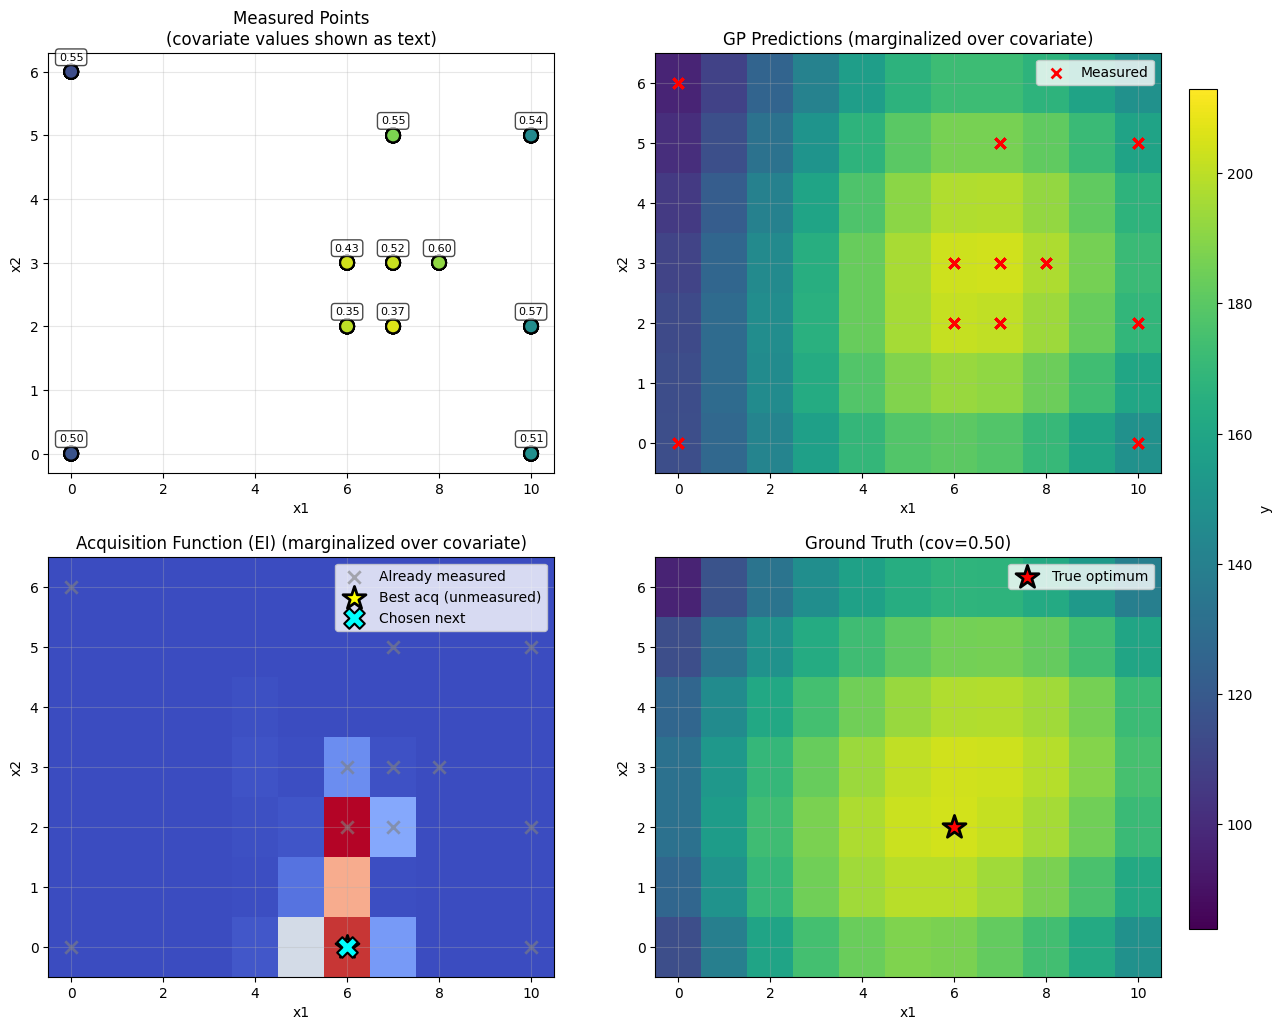

{'x1': np.float64(6.0), 'x2': np.float64(0.0)}
=== BO iteration 10/12 ===


sample: 100%|██████████| 1200/1200 [00:05<00:00, 230.44it/s, 15 steps of size 4.47e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.56      0.46      1.52      0.80      2.23    354.42      1.01
k_length[1]      2.63      0.69      2.59      1.39      3.59    394.27      1.01
k_length[2]     11.02      2.97     10.56      6.58     15.78    392.21      1.00
    k_scale      3.66      2.48      2.96      0.78      6.67    298.12      1.01
      noise      0.01      0.00      0.01      0.01      0.01    741.25      1.00

Computing robust acquisition over 1300 scenarios (65 grid points x 20 covariate samples)...
  best_f (scaled): 1.159836
  Acq values stats: min=0.000000, max=0.000041, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000002
Computing robust acquisition over 1540 scenarios (77 grid points x 20 covariate samples)...
  best_f (scaled): 1.159836


KeyboardInterrupt: 

In [15]:
# simulate an example run with two steerable parameters (x1, x2),
# one non-steerable covariate (cov1), and a single 1D objective (y).
bo_params = [
    BO_Parameter(name="x1", bounds=(0.0, 10.0), param_type="float", spacing=1.0),
    BO_Parameter(name="x2", bounds=(0.0, 6.0), param_type="float", spacing=1.0),
]
bo_covariates = [
    BO_Covariate(name="cov1"),
]
bo_objective = BO_Objective(name="y", goal="maximize")

# Noise knob for the mock measurements (0.0 -> deterministic)
MOCK_NOISE_SCALE = 1.0


class MockMicroscope:
    def run_experiment(self, df_acquire):
        return mock_df_results(
            df_acquire=df_acquire, n_samples=10, noise_scale=MOCK_NOISE_SCALE
        )


class DemoBOptGPAX(BOptGPAX):
    def _create_df_acquire_for_exp_cycle(self, parameters: dict) -> pd.DataFrame:
        # One acquisition point per cycle; microscope will return multiple samples.
        return pd.DataFrame([parameters])

    def run(self):
        df_results = pd.DataFrame()

        # initial exploration
        X_init, _ = self._select_initial_samples(k=3)
        df_acquire_init = pd.DataFrame(
            X_init, columns=[p.name for p in self.parameters_to_optimize]
        )
        df_new_results = self.microscope.run_experiment(df_acquire_init)
        df_results = pd.concat([df_results, df_new_results], ignore_index=True)

        for e in range(self.n_iterations):
            print(f"=== BO iteration {e+1}/{self.n_iterations} ===")
            next_params = self._determine_next_parameters(df_results, verbose=True)
            print(next_params)

            df_acquire = pd.DataFrame([next_params])
            df_new_results = self.microscope.run_experiment(df_acquire)
            df_results = pd.concat([df_results, df_new_results], ignore_index=True)

            self.iteration += 1


bo_agent = DemoBOptGPAX(
    pipeline=(),
    microscope=MockMicroscope(),
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=12,
    acquisition_function="ei",  # try: "ei" or "ucb"
    ucb_beta=4.0,
    ei_xi=0.0,
)

bo_agent.run()

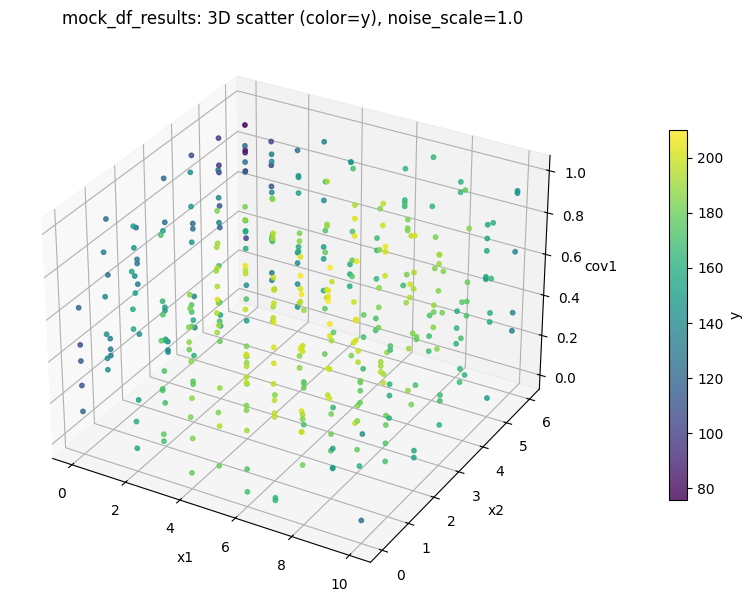

In [ ]:
# 3D visualization of the mock data distribution
from mpl_toolkits.mplot3d import Axes3D

# Build a full (x1,x2) grid and sample multiple cov1/y per point
x_total = bo_agent.x_total_linespace
df_acquire_grid = pd.DataFrame(x_total, columns=[p.name for p in bo_params])
df_mock = mock_df_results(
    df_acquire=df_acquire_grid, n_samples=5, noise_scale=MOCK_NOISE_SCALE
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_mock["x1"].values,
    df_mock["x2"].values,
    df_mock["cov1"].values,
    c=df_mock["y"].values,
    cmap="viridis",
    s=10,
    alpha=0.8,
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("cov1")
ax.set_title(f"mock_df_results: 3D scatter (color=y), noise_scale={MOCK_NOISE_SCALE}")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.12)
cbar.set_label("y")
plt.show()